In [ ]:
import random
import statistics
from pathlib import Path
import matplotlib.pyplot as plt
from py_fdr.main import load_patterns, scan_rulesets_file, FDRCompiler, FDR

# Helper: run one experiment set
def run_experiment(pattern_counts, short_patterns_path, rulesets_path, max_rulesets=0, seed=1234):
    short_patterns = list(load_patterns(short_patterns_path))
    random.seed(seed)
    results_summary = []

In [ ]:
# Plot helper
def plot_results(summary):
    xs = [r['n_patterns'] for r in summary]
    ys = [r['avg_time_ms'] for r in summary]
    plt.figure(figsize=(8,4))
    plt.plot(xs, ys, marker='o')
    plt.xlabel('Number of patterns')
    plt.ylabel('Average ruleset scan time (ms)')
    plt.title('FDR average per-ruleset scan time')
    plt.grid(True)
    plt.show()

In [ ]:
# Quick verification run (small sizes, limited rulesets)
base = Path(__file__).parent
short_patterns = (base.parent.parent / 'dataset' / 'short_patterns.txt')
# Prefer experiments/rulesets.txt if present, else fall back to dataset/rulesets.txt
rulesets_candidate = base / 'rulesets.txt'
if rulesets_candidate.exists():
    rulesets = str(rulesets_candidate)
else:
    rulesets = str(base.parent.parent / 'dataset' / 'rulesets.txt')

print('Using short_patterns:', short_patterns)
print('Using rulesets:', rulesets)

summary = run_experiment([8,16,24], str(short_patterns), rulesets, max_rulesets=10)
plot_results(summary)

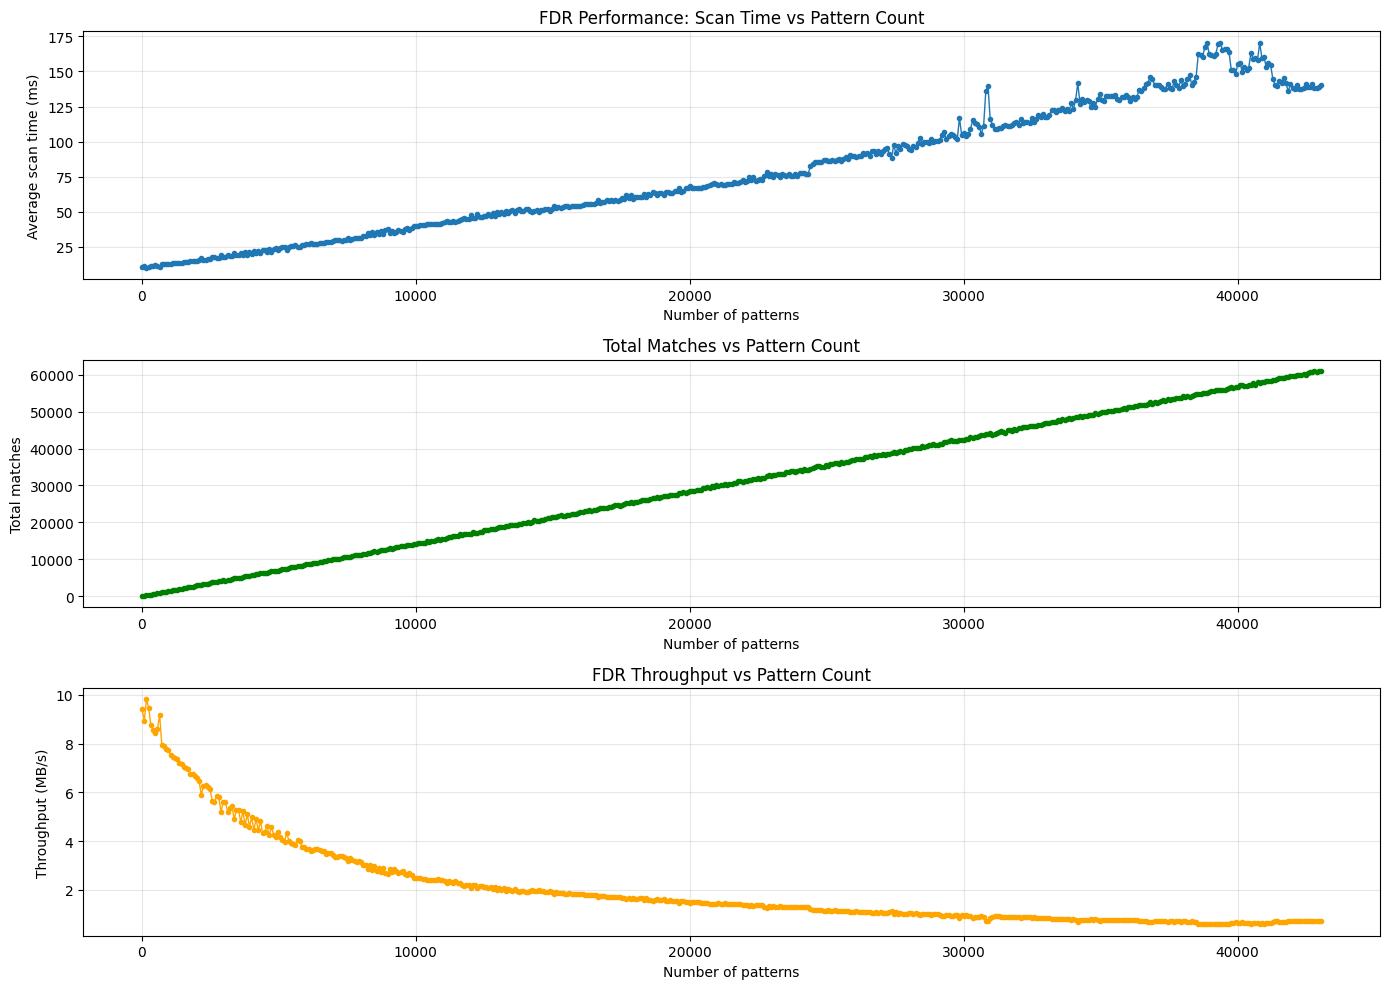


Experiment Summary:
  Pattern count range: 8 to 43048
  Avg time range: 10.18 to 170.50 ms
  Throughput range: 0.59 to 9.82 MB/s
  Total data points: 539


In [5]:
# Load and plot experiment results from CSV
import pandas as pd
from matplotlib import pyplot as plt

# Load the experiment data
df = pd.read_csv(r'D:\Projects\string-matchers\src\py_fdr\experiments\output2\experiment_progress.csv')

# Create multiple plots for comprehensive analysis
fig, axes = plt.subplots(3, figsize=(14, 10))

# Plot 1: Average time vs number of patterns
axes[0].plot(df['n_patterns'], df['avg_time_ms'], marker='o', linewidth=1, markersize=3)
axes[0].set_xlabel('Number of patterns')
axes[0].set_ylabel('Average scan time (ms)')
axes[0].set_title('FDR Performance: Scan Time vs Pattern Count')
axes[0].grid(True, alpha=0.3)

# Plot 2: Total matches vs number of patterns
axes[1].plot(df['n_patterns'], df['total_matches'], marker='o', linewidth=1, markersize=3, color='green')
axes[1].set_xlabel('Number of patterns')
axes[1].set_ylabel('Total matches')
axes[1].set_title('Total Matches vs Pattern Count')
axes[1].grid(True, alpha=0.3)

# Plot 3: Throughput (MB/s)
df['throughput_mbs'] = (df['total_bytes'] / 1e6) / (df['avg_time_ms'] / 1000)
axes[2].plot(df['n_patterns'], df['throughput_mbs'], marker='o', linewidth=1, markersize=3, color='orange')
axes[2].set_xlabel('Number of patterns')
axes[2].set_ylabel('Throughput (MB/s)')
axes[2].set_title('FDR Throughput vs Pattern Count')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nExperiment Summary:")
print(f"  Pattern count range: {df['n_patterns'].min()} to {df['n_patterns'].max()}")
print(f"  Avg time range: {df['avg_time_ms'].min():.2f} to {df['avg_time_ms'].max():.2f} ms")
print(f"  Throughput range: {df['throughput_mbs'].min():.2f} to {df['throughput_mbs'].max():.2f} MB/s")
print(f"  Total data points: {len(df)}")